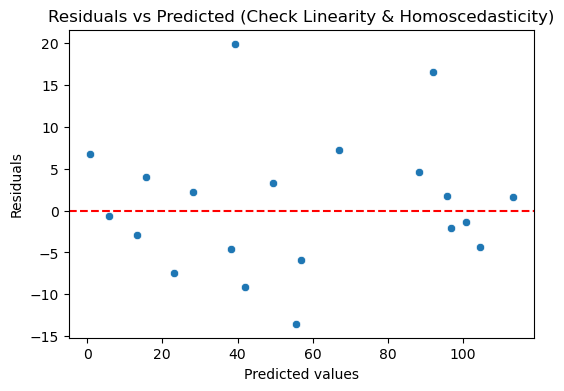

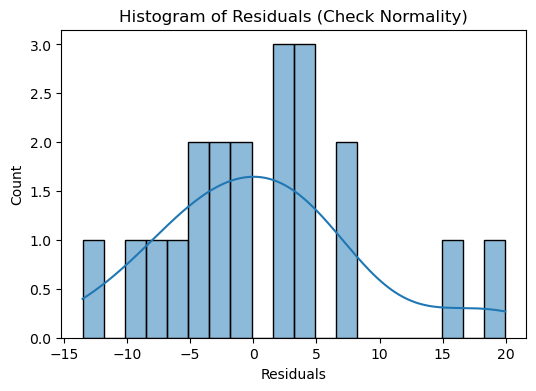

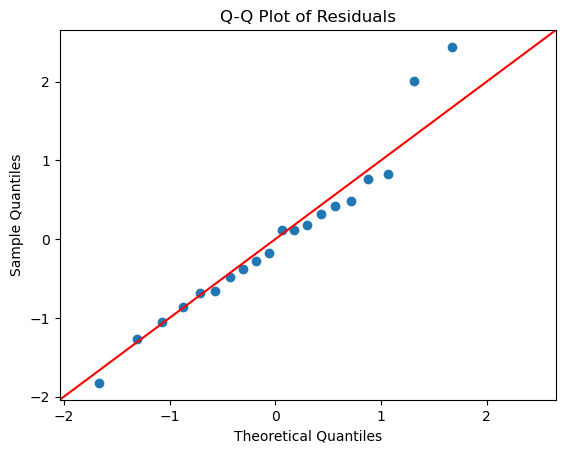

Durbin-Watson statistic: 1.9772804875155783


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

# Generate some sample data
np.random.seed(42)
X = np.linspace(1, 50, 100).reshape(-1, 1)   # Predictor
y = 2.5 * X.flatten() + np.random.normal(0, 10, 100)  # Linear relationship + noise

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Residuals
residuals = y_test - y_pred

# -----------------------------
# 1. Residuals vs Predicted plot
# -----------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Check Linearity & Homoscedasticity)")
plt.show()

# -----------------------------
# 2. Histogram of residuals (Normality)
# -----------------------------
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, bins=20)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals (Check Normality)")
plt.show()

# -----------------------------
# 3. Q-Q plot (Normality)
# -----------------------------
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

# -----------------------------
# 4. Durbin-Watson Test (Independence of errors)
# -----------------------------
dw_stat = sm.stats.durbin_watson(residuals)
print("Durbin-Watson statistic:", dw_stat)
